# 4. Simulation statistics

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim extra
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.mocka      as mk
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Define paths used throughout
path = f'/lhome/nicholas/software/workdir/mocka/simulations/mocka'
fdir = '/lhome/nicholas/Nextcloud/latex/paperMOCKA/figures'
vdir = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/data_varsim'

---
## $\gamma$ Doradus 
---

In [9]:
ids = mk.fetch_contaminants(path, star='GDOR', batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [00:04<00:00,

Number of GDOR stars contaminated: 2650


100%|██████████████████████████████████████████████████| 4000/4000 [00:09<00:00,


<IPython.core.display.Javascript object>


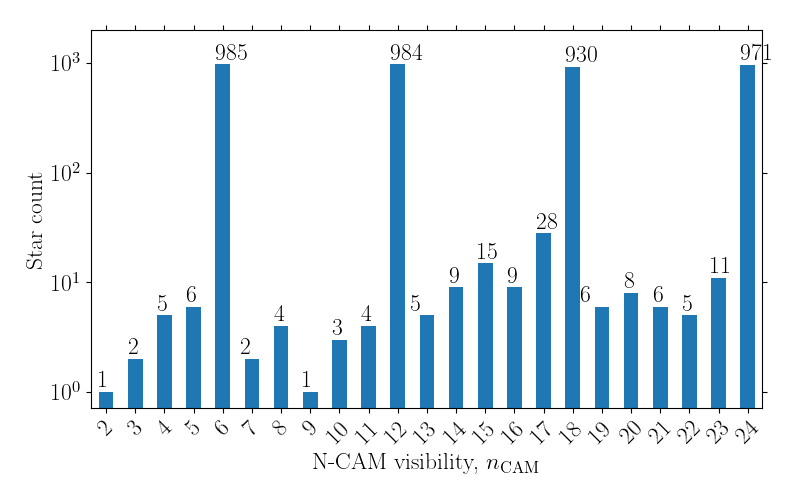

In [10]:
df = mk.fetch_table(path, star='GDOR', batch='affogato')
mk.plot_ncam_hist(df)

---
## SPB stars
---

In [73]:
ids = mk.fetch_contaminants(path, star='SPB', batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 942.23it/s]         

Number of SPB stars contaminated: 2957


100%|██████████████████████████████████████████████████| 4000/4000 [00:08<00:00, 447.22it/s]         


<IPython.core.display.Javascript object>


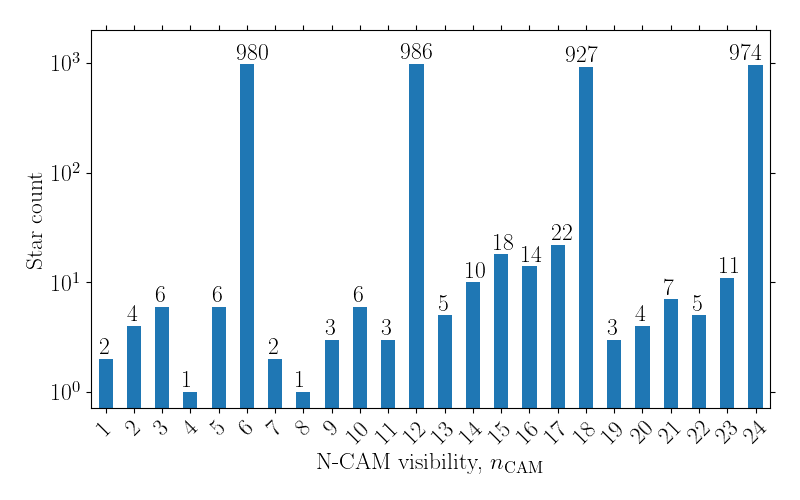

In [74]:
df = mk.fetch_table(path, star='SPB', batch='affogato')
mk.plot_ncam_hist(df)
# Save figure for referee
# fig.savefig(f'{fdir}/referee_historgram_starcount.png', bbox_inches='tight', dpi=200)

---
## $\delta$ Scuti
---

In [75]:
ids = mk.fetch_contaminants(path, star='DSCT', batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 936.47it/s]         

Number of DSCT stars contaminated: 2888


100%|██████████████████████████████████████████████████| 4000/4000 [00:08<00:00, 461.33it/s]         


<IPython.core.display.Javascript object>


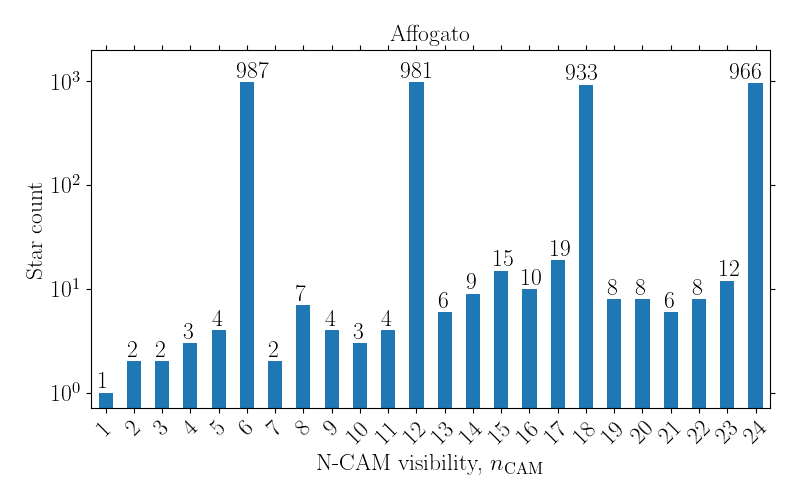

In [79]:
df = mk.fetch_table(path, star='DSCT', batch='affogato')
mk.plot_ncam_hist(df, title='Affogato')

---
## $\beta$ Cephei
---

In [11]:
ids = mk.fetch_contaminants(path, star='BCEP', batch='affogato')

100%|██████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 727.94it/s]                                                                  

Number of BCEP stars contaminated: 1460


100%|██████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 388.83it/s]                                                                  


<IPython.core.display.Javascript object>


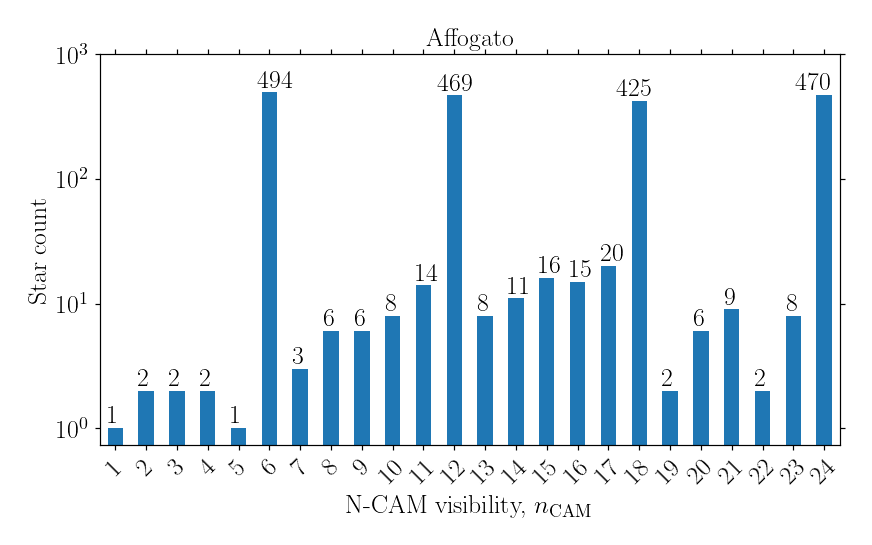

In [9]:
df = mk.fetch_table(path, star='BCEP', batch='affogato')
mk.plot_ncam_hist(df, title='Affogato')

---
## RR Lyrae
---

In [28]:
# Check simulated light curve
# mk.plot_lc_io(path, 'RRLYR', 'affogato', ID=1, plot_input=True, figsize=(9,5));

In [14]:
ids = mk.fetch_contaminants(path, star='RRLYR', batch='affogato')

100%|██████████████████████████████████████████████████| 2000/2000 [00:02<00:00,

Number of RRLYR stars contaminated: 1243


In [15]:
ids[:10]

array([ 2,  7,  8, 11, 12, 15, 16, 17, 18, 19])

100%|██████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 476.44it/s]                                                                  


<IPython.core.display.Javascript object>


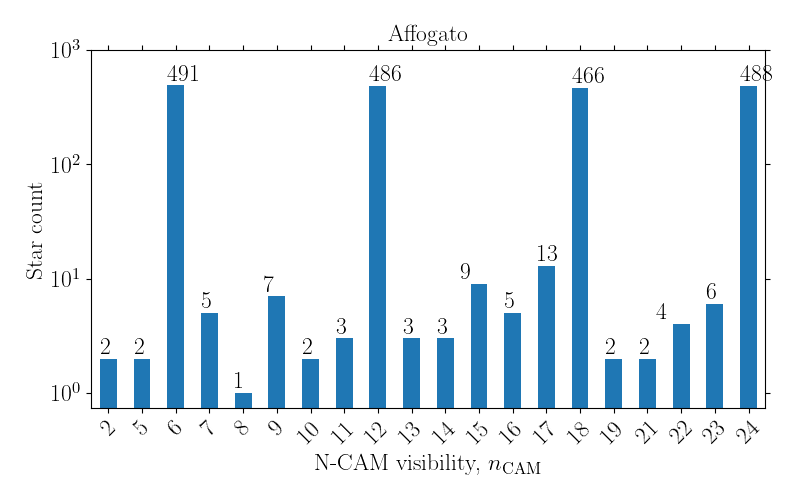

In [8]:
df = mk.fetch_table(path, star='RRLYR', batch='affogato')
mk.plot_ncam_hist(df, title='Affogato')

---
## Cepheid
---

<IPython.core.display.Javascript object>


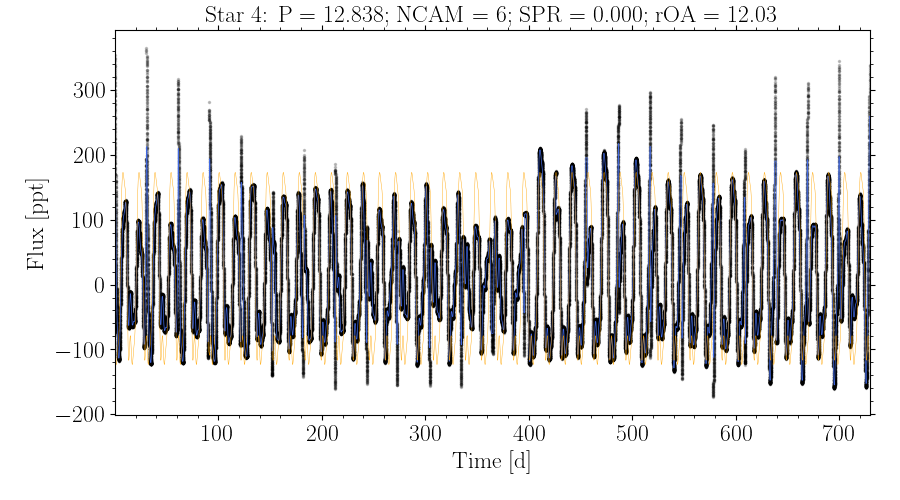

In [26]:
# Check simulated light curve
mk.plot_lc_io(path, 'CEPH', 'affogato', ID=4, plot_input=True, figsize=(9,5));

In [24]:
ids = mk.fetch_contaminants(path, star='CEPH', batch='affogato')

100%|██████████████████████████████████████████████████| 2000/2000 [00:03<00:00, 561.97it/s]                                                                  

Number of CEPH stars contaminated: 1457


100%|██████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 390.12it/s]                                                                  


<IPython.core.display.Javascript object>


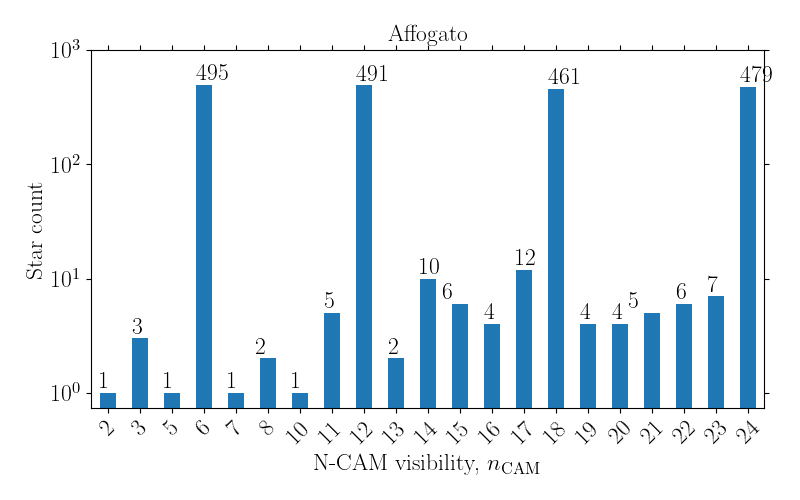

In [25]:
df = mk.fetch_table(path, star='CEPH', batch='affogato')
mk.plot_ncam_hist(df, title='Affogato')

---
## sdBV pulsators
---

---
## WD pulsators
---

In [188]:
star  = 'WD'
bacth = 'affogato'
# name  = 'DAV_TIC033986466'
# name  = 'DAV_TIC422526868'
name = 'DBV_TIC219074038'
# name = 'DOV_TIC035062562'
ID = 6

<IPython.core.display.Javascript object>


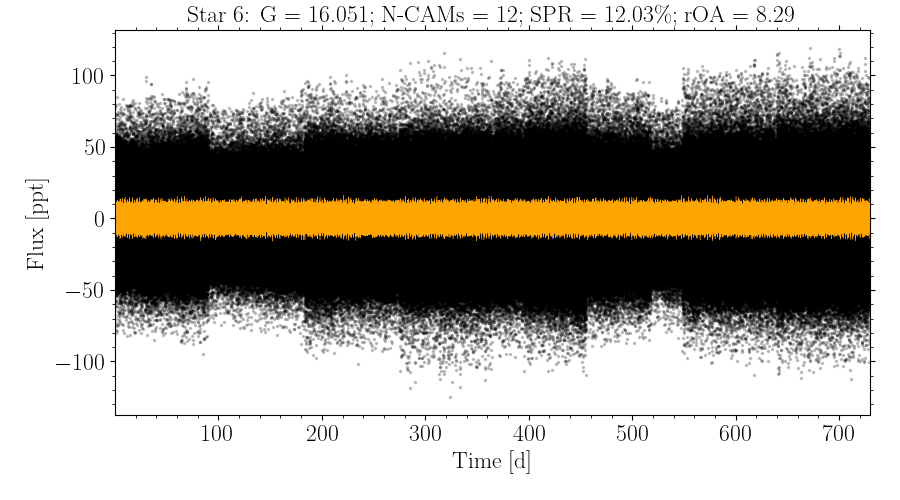

In [174]:
# Plot simulated light curve
mk.plot_lc_io_compact(path, star, batch, name, ID, plot_input=True, figsize=(9,5));

<IPython.core.display.Javascript object>


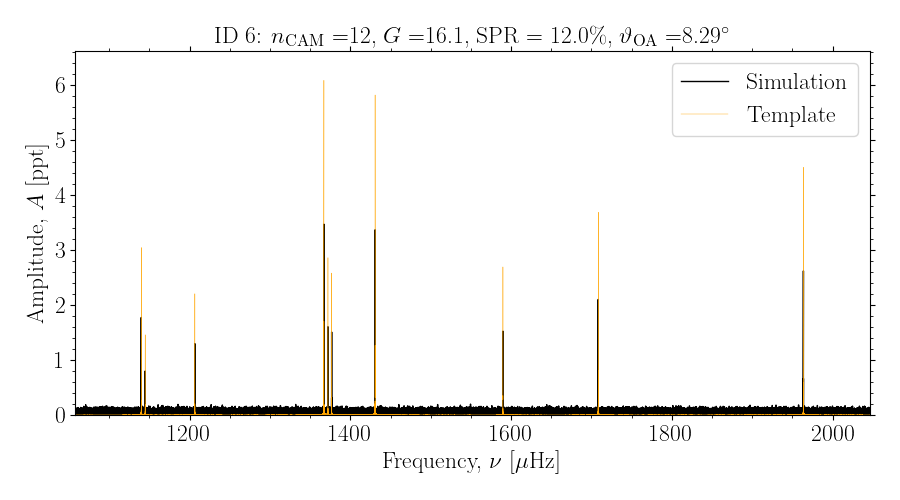

In [178]:
# Plot a amplitude spectrum
mk.plot_ft_io_compact(path, star, batch, name, ID, figsize=(9,5));

<IPython.core.display.Javascript object>


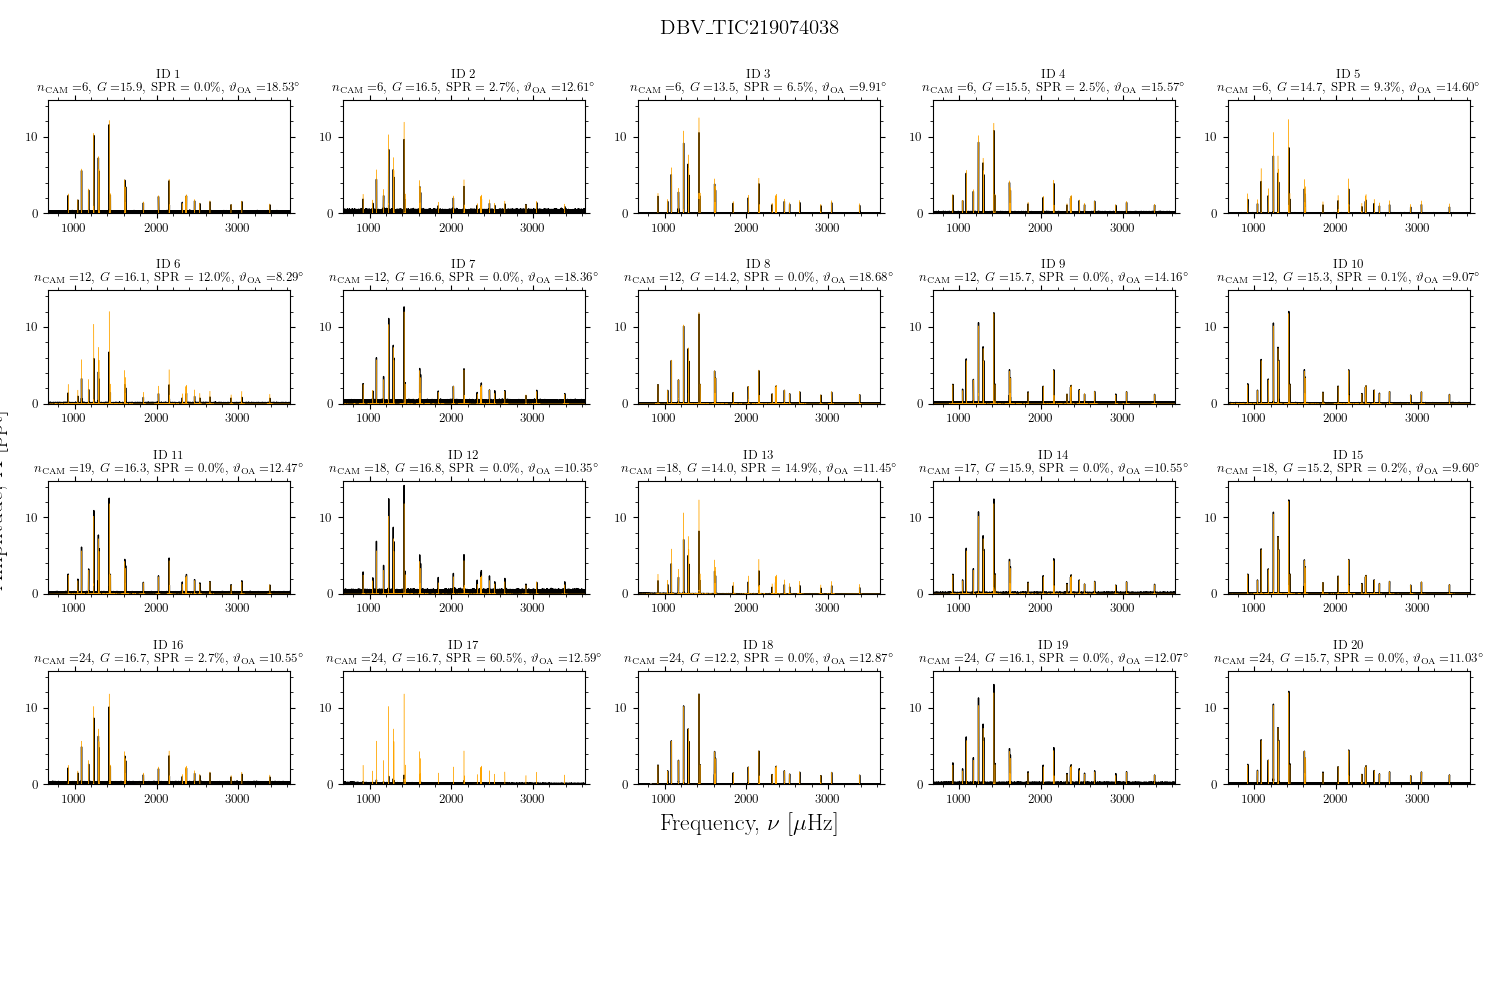

100%|██████████████████████████████████████████████████| 20/20 [02:24<00:00,  7.25s/it]                                                                       


In [189]:
# Plot amplitude spectrum comparison between injected and simulated
fig, ax = mk.plot_ft_io_compact_all(path, star, batch, name)
fig.savefig(f'{fdir}/fourier_io_WD_{name}.png', bbox_inches='tight', dpi=300)